In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("../../").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

## Load data

In [2]:
# Agent QA results (latest file)
agent_path = sorted((PROJECT_ROOT / "datasets/experiments/agent/results").glob("qa_results_*.csv"))[-1]
print("Agent file  :", agent_path.name)
agent = pd.read_csv(agent_path)
agent["score"] = agent["judge_score"] / 10.0   # normalise 0-10 → 0-1

# LLM-only results (clean CFB run)
llm_path = PROJECT_ROOT / "datasets/experiments/llm/reasoning/cfb_judged_20260625_011355.csv"
print("LLM-only file:", llm_path.name)
llm = pd.read_csv(llm_path)
llm = llm.rename(columns={"judge_score": "score"})

print(f"\nAgent rows : {len(agent):,}")
print(f"LLM-only rows: {len(llm):,}")

Agent file  : qa_results_20260624_234232.csv
LLM-only file: cfb_judged_20260625_011355.csv

Agent rows : 6,270
LLM-only rows: 6,270


---
## Plot 1 — Agent pipeline vs plain LLM
Same CFB dataset, same question types (LR / PE / NR), different answering strategies.
The agent uses a supervisor + 3 sub-agents with retrieval tools.
The plain LLM receives the document extract directly in the prompt.

Both scores are normalised to [0, 1] and judged by the same criteria.

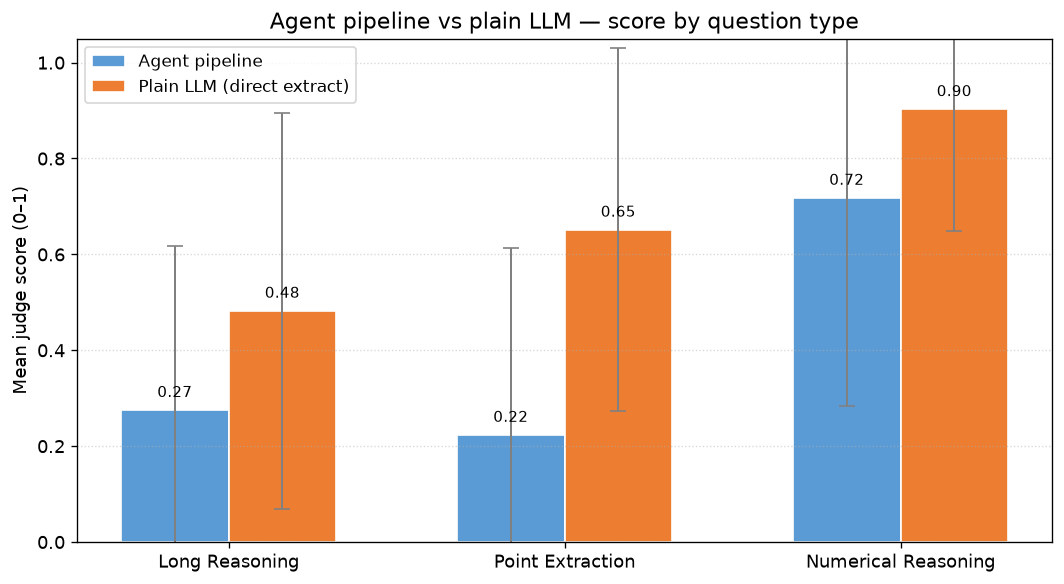

Delta (LLM - Agent):
  LR: +0.207  (LLM better)
  PE: +0.428  (LLM better)
  NR: +0.185  (LLM better)


In [3]:
type_order  = ["LR", "PE", "NR"]
type_labels = {"LR": "Long Reasoning", "PE": "Point Extraction", "NR": "Numerical Reasoning"}
type_colors = {"LR": "#1f77b4", "PE": "#ff7f0e", "NR": "#2ca02c"}

agent_means = {qt: agent[agent["question_type"] == qt]["score"].mean() for qt in type_order}
agent_stds  = {qt: agent[agent["question_type"] == qt]["score"].std()  for qt in type_order}
llm_means   = {qt: llm[llm["question_type"]   == qt]["score"].mean() for qt in type_order}
llm_stds    = {qt: llm[llm["question_type"]   == qt]["score"].std()  for qt in type_order}

x     = np.arange(len(type_order))
width = 0.32

fig, ax = plt.subplots(figsize=(9, 5))

bars_agent = ax.bar(x - width/2,
                    [agent_means[qt] for qt in type_order],
                    width, label="Agent pipeline",
                    color="#5b9bd5", edgecolor="white",
                    yerr=[agent_stds[qt] for qt in type_order],
                    capsize=5, error_kw={"elinewidth": 1.2, "ecolor": "grey"})

bars_llm   = ax.bar(x + width/2,
                    [llm_means[qt] for qt in type_order],
                    width, label="Plain LLM (direct extract)",
                    color="#ed7d31", edgecolor="white",
                    yerr=[llm_stds[qt] for qt in type_order],
                    capsize=5, error_kw={"elinewidth": 1.2, "ecolor": "grey"})

# Annotate bar tops
for bars, means in [(bars_agent, agent_means), (bars_llm, llm_means)]:
    for bar, qt in zip(bars, type_order):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.02,
                f"{means[qt]:.2f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([type_labels[qt] for qt in type_order], fontsize=11)
ax.set_ylabel("Mean judge score (0–1)", fontsize=11)
ax.set_title("Agent pipeline vs plain LLM — score by question type", fontsize=13)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10)
ax.grid(axis="y", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

print("Delta (LLM - Agent):")
for qt in type_order:
    delta = llm_means[qt] - agent_means[qt]
    print(f"  {qt}: {delta:+.3f}  ({'LLM better' if delta > 0 else 'Agent better'})")

---
## Plot 2 — Does supervisor confidence predict answer quality?
The supervisor assigns a confidence value [0, 1] to each answer.
76% of answers get confidence = 0. This plot checks whether higher confidence
actually correlates with a higher judge score — i.e. does the agent know when it's right?

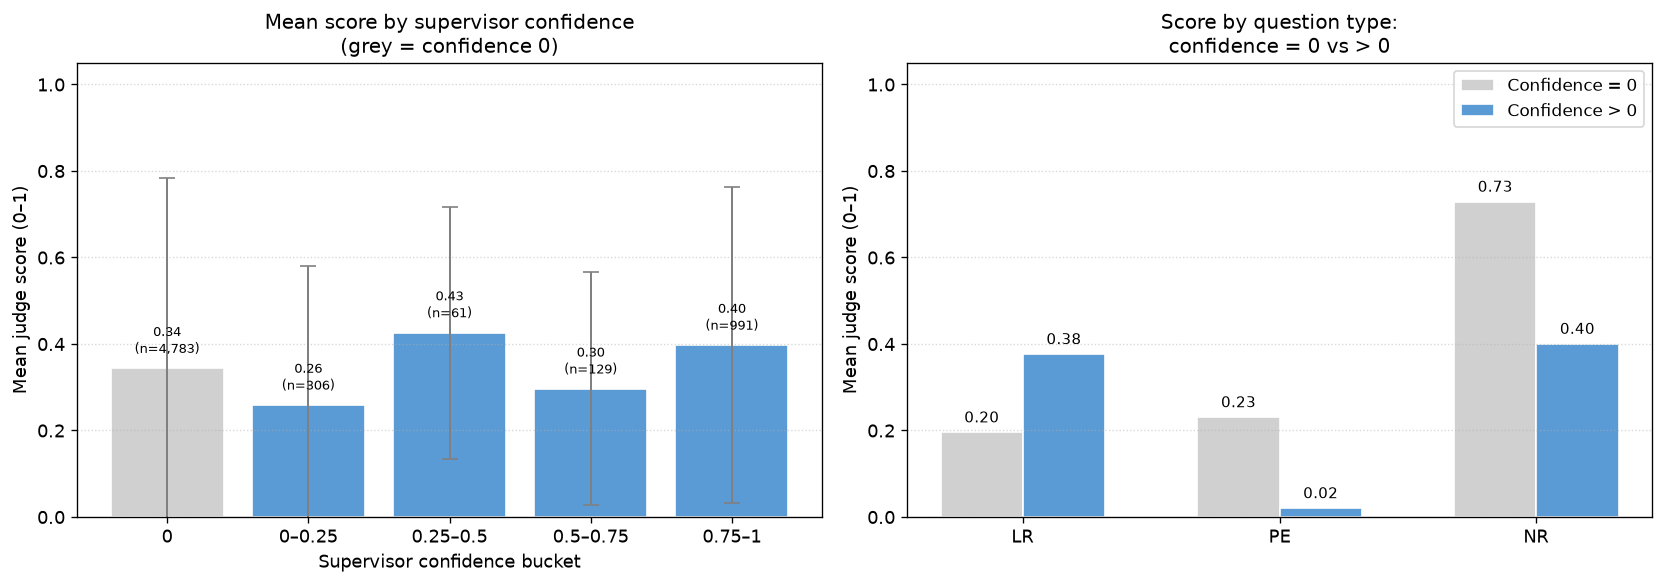

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: mean judge score by confidence bucket
bins   = [0.0, 0.01, 0.25, 0.5, 0.75, 1.01]
labels = ["0", "0–0.25", "0.25–0.5", "0.5–0.75", "0.75–1"]
agent["conf_bucket"] = pd.cut(agent["supervisor_confidence"], bins=bins,
                               labels=labels, right=False)

bucket_means = agent.groupby("conf_bucket", observed=True)["score"].mean()
bucket_stds  = agent.groupby("conf_bucket", observed=True)["score"].std()
bucket_n     = agent.groupby("conf_bucket", observed=True)["score"].count()

colors = ["#d0d0d0"] + ["#5b9bd5"] * (len(labels) - 1)
bars = axes[0].bar(labels, bucket_means.values,
                   color=colors, edgecolor="white",
                   yerr=bucket_stds.values, capsize=5,
                   error_kw={"elinewidth": 1.2, "ecolor": "grey"})
for bar, n, mean in zip(bars, bucket_n.values, bucket_means.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.025,
                 f"{mean:.2f}\n(n={n:,})", ha="center", va="bottom", fontsize=8)
axes[0].set_xlabel("Supervisor confidence bucket", fontsize=11)
axes[0].set_ylabel("Mean judge score (0–1)", fontsize=11)
axes[0].set_title("Mean score by supervisor confidence\n(grey = confidence 0)", fontsize=12)
axes[0].set_ylim(0, 1.05)
axes[0].grid(axis="y", linestyle=":", alpha=0.5)

# Right: per question type — score at confidence=0 vs >0
type_order  = ["LR", "PE", "NR"]
type_colors_hex = {"LR": "#1f77b4", "PE": "#ff7f0e", "NR": "#2ca02c"}
x     = np.arange(len(type_order))
width = 0.32

means_zero = [agent[(agent["question_type"] == qt) &
                    (agent["supervisor_confidence"] == 0)]["score"].mean()
              for qt in type_order]
means_pos  = [agent[(agent["question_type"] == qt) &
                    (agent["supervisor_confidence"] > 0)]["score"].mean()
              for qt in type_order]

b0 = axes[1].bar(x - width/2, means_zero, width,
                 label="Confidence = 0", color="#d0d0d0", edgecolor="white")
b1 = axes[1].bar(x + width/2, means_pos,  width,
                 label="Confidence > 0", color="#5b9bd5", edgecolor="white")

for bars, means in [(b0, means_zero), (b1, means_pos)]:
    for bar, mean in zip(bars, means):
        if not np.isnan(mean):
            axes[1].text(bar.get_x() + bar.get_width()/2,
                         bar.get_height() + 0.015,
                         f"{mean:.2f}", ha="center", va="bottom", fontsize=9)

axes[1].set_xticks(x)
axes[1].set_xticklabels(type_order, fontsize=11)
axes[1].set_ylabel("Mean judge score (0–1)", fontsize=11)
axes[1].set_title("Score by question type:\nconfidence = 0 vs > 0", fontsize=12)
axes[1].set_ylim(0, 1.05)
axes[1].legend(fontsize=10)
axes[1].grid(axis="y", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()